# 4장 1강: 단순선형회귀 이론 — 실습문제

## 실습 목표

- 최소제곱법의 공식을 이용해 단순선형회귀의 기울기와 절편을 직접 계산합니다.
- 회귀계수, 예측값, 잔차, SSE, SST, 결정계수 $R^2$의 의미를 설명합니다.
- 회귀선과 잔차 플롯을 함께 확인하여 모델의 설명력과 적합 타당성을 평가합니다.

## 실습 환경 / 데이터

- Python, NumPy, pandas, Matplotlib
- `ames_housing(1).csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `YearBuilt`
- 이번 강의는 회귀 원리를 확인하는 과정이므로 회귀계수와 평가지표를 NumPy로 직접 계산합니다.

## 실습 준비

아래 셀을 실행하여 데이터를 불러오고 데이터 크기, 결측치, 컬럼을 확인하세요.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_candidates = [
    Path("ames_housing(1).csv"),
    Path("ames_housing.csv"),
    Path("upload/ames_housing(1).csv"),
]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing CSV 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()


데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적으로 매매가격을 설명하는 회귀직선 구하기

`GrLivArea`를 독립변수 $x$, `SalePrice`를 종속변수 $y$로 사용하여 최소제곱 회귀직선을 직접 구하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. $x$와 $y$의 평균을 계산하세요.
3. 아래 공식을 이용하여 기울기 $\beta_1$과 절편 $\beta_0$를 계산하세요.

$$
\beta_1 = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2},
\qquad
\beta_0 = \bar{y}-\beta_1\bar{x}
$$

4. 회귀식을 출력하고, 생활면적이 1,500일 때의 매매가격을 예측하세요.
5. 산점도 위에 회귀직선을 그리세요.

### 질문

1. 기울기 $\beta_1$은 이 데이터에서 무엇을 의미하나요?
 - 생활면적이 1단위 증가할 때마다 모델이 예측하는 매매 가격이 평균적으로 약 107.13만큼 증가한다는 의미

2. 절편 $\beta_0$는 무엇을 의미하며, 현실적으로 그대로 해석해도 되나요?
 - 생활면적이 0일 때 예측 가격 약 18,569를 의미한다.
 - 면적이 0인 주택은 고간측 범위나 현실적 분석 대상과는 거리가 있기 때문에 과도한 해석을 피해야 한다.

3. 최소제곱법은 어떤 기준으로 이 회귀직선을 선택하나요?
 - 실제값과 예측값의 차이인 잔차를 제곱해 모두 더한 SSE값이 가장 작아지는 기울기와 절편을 선택한다.

x 평균: 1515.46
y 평균: 180921.20
기울기 beta_1: 107.1304
절편 beta_0: 18569.0259
회귀식: SalePrice = 18569.0259 + 107.1304 × GrLivArea
GrLivArea=1500 예측 가격: 179,264.56


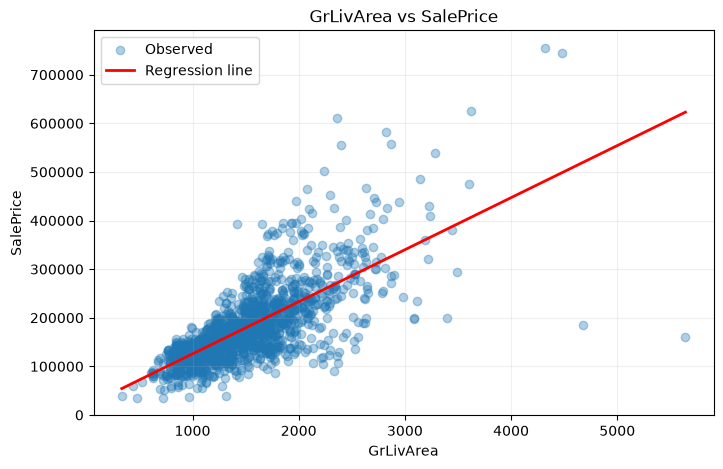

In [2]:
# 여기에 코드를 작성하세요.
reg_data = df[["GrLivArea", "SalePrice"]].dropna()

x = reg_data["GrLivArea"].to_numpy(dtype=float)
y = reg_data["SalePrice"].to_numpy(dtype=float)

x_mean = x.mean()
y_mean = y.mean()

beta_1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
beta_0 = y_mean - beta_1 * x_mean

target_area = 1500
predicted_price_1500 = beta_0 + beta_1 * target_area

print(f"x 평균: {x_mean:.2f}")
print(f"y 평균: {y_mean:.2f}")
print(f"기울기 beta_1: {beta_1:.4f}")
print(f"절편 beta_0: {beta_0:.4f}")
print(f"회귀식: SalePrice = {beta_0:.4f} + {beta_1:.4f} × GrLivArea")
print(f"GrLivArea=1500 예측 가격: {predicted_price_1500:,.2f}")

x_line = np.linspace(x.min(), x.max(), 200)
y_line = beta_0 + beta_1 * x_line

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.35, label="Observed")
plt.plot(x_line, y_line, color="red", linewidth=2, label="Regression line")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


---

## 필수 2. 결정계수와 잔차로 회귀모델 평가하기

필수 1에서 구한 `beta0`, `beta1`, `x`, `y`를 이용하여 모델의 설명력과 잔차 분포를 평가하세요.

### 수행 요구사항

1. 예측값 $\hat{y}$과 잔차 $e=y-\hat{y}$를 계산하세요.
2. SSE와 SST를 계산한 뒤 $R^2=1-SSE/SST$를 구하세요.
3. 잔차의 평균과 평균절대잔차(MAE)를 계산하세요.
4. 예측값을 x축, 잔차를 y축으로 하는 잔차 플롯을 그리세요. $y=0$ 기준선을 표시하세요.
5. 절대잔차가 가장 큰 관측치의 생활면적, 실제가격, 예측가격, 잔차를 출력하세요.

### 질문

1. $R^2$은 이 모델에서 무엇을 의미하나요?
 - 현재 데이터에서 매매 가격 전체 변동의 약 50.2%를 생활 면적과의 선형회귀 모델이 선명하다는 의미

2. 잔차 평균이 0에 가깝다는 사실만으로 좋은 모델이라고 판단할 수 있나요?
 - ㄴㄴ 양의 잔차와 음의 잔차가 상쇄될 수 있다. 잔차의 크기와 패턴 파악이 추가적으로 필요하다.

3. 잔차 플롯에서 오차의 폭과 극단적인 잔차는 어떻게 보이나요?
 - 높은 예측 가격 구간에서 잔차의 퍼짐이 커지는 경향과 회귀선에서 매우 멀리 떨어진 관측치가 보인다.

4. 회귀계수, $R^2$, 잔차를 종합할 때 이 모델은 매매가격을 충분히 설명한다고 볼 수 있나요?
 -  생활 면적과 가격의 양의 관계 및 약 절반의 변동성을 설명하지만 나머지 약 49.8%는 설명하지 못했다.
 - 오차의 퍼짐과 극단값도 차이가 컸다.
 - 기본 모델 로 모델링을 진행할 수 있다는 것을 확인할 수 있다.

SSE = 4,584,171,086,113.13
SST = 9,207,911,334,609.98
R² = 0.5021
잔차 평균 = 0.0000
MAE = 37,638.73

[절대잔차가 가장 큰 관측치]
GrLivArea = 5,642.00
실제가격 = 160,000.00
예측가격 = 622,998.51
잔차 = -462,998.51


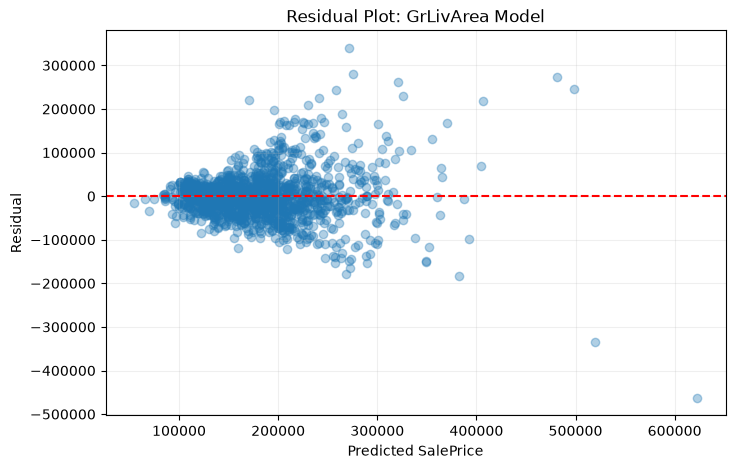

In [5]:
# 여기에 코드를 작성하세요.
y_pred = beta_0 + beta_1 * x
residuals = y - y_pred

sse = np.sum(residuals ** 2)
sst = np.sum((y - y_mean) ** 2)

r_squared = 1 - sse / sst
residual_mean = residuals.mean()

mae = np.mean(np.abs(residuals))
max_error_idx = np.argmax(np.abs(residuals))

print(f"SSE = {sse:,.2f}")
print(f"SST = {sst:,.2f}")
print(f"R² = {r_squared:.4f}")
print(f"잔차 평균 = {residual_mean:.4f}")
print(f"MAE = {mae:,.2f}")

print("\n[절대잔차가 가장 큰 관측치]")
print(f"GrLivArea = {x[max_error_idx]:,.2f}")
print(f"실제가격 = {y[max_error_idx]:,.2f}")
print(f"예측가격 = {y_pred[max_error_idx]:,.2f}")
print(f"잔차 = {residuals[max_error_idx]:,.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.35)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Residual Plot: GrLivArea Model")
plt.grid(alpha=0.2)
plt.show()

---

## 과제. 건축연도로 매매가격을 설명하는 단순회귀 분석

`YearBuilt`를 독립변수, `SalePrice`를 종속변수로 사용하여 필수 문제와 동일한 수준의 단순선형회귀 분석을 독립적으로 수행하세요.

### 수행 요구사항

1. 최소제곱법으로 기울기와 절편을 직접 계산하세요.
2. 예측값, 잔차, SSE, SST, $R^2$을 계산하세요.
3. 건축연도가 2000년인 주택의 매매가격을 예측하세요.
4. 산점도와 회귀직선, 잔차 플롯을 그리세요.
5. 아래 질문에 답하는 5~7문장의 결론을 작성하세요.

### 질문

1. 기울기와 절편은 각각 무엇을 의미하나요?
2. $R^2$을 기준으로 모델의 설명력은 어떠한가요?
3. 잔차 플롯을 기준으로 모델의 적합성에 주의할 점이 있나요?
4. 이 모델의 적용 한계 또는 개선 방향을 한 가지 이상 제시하세요.

> 과제는 필수 문제와 동일한 수준이며, 새로운 고급 기법을 사용할 필요는 없습니다.


x 평균: 1971.27
y 평균: 180921.20
기울기 beta_1: 1375.3735
절편 beta_0: -2530308.2457
회귀식: SalePrice = -2530308.2457 + 1375.3735 × YearBuilt
YearBuilt=2000 예측 가격: 220,438.69
SSE = 6,690,269,293,939.84
SST = 9,207,911,334,609.98
R² = 0.2734


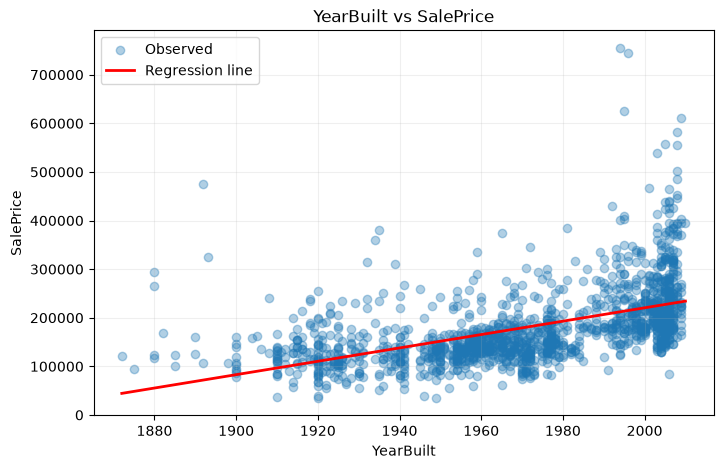

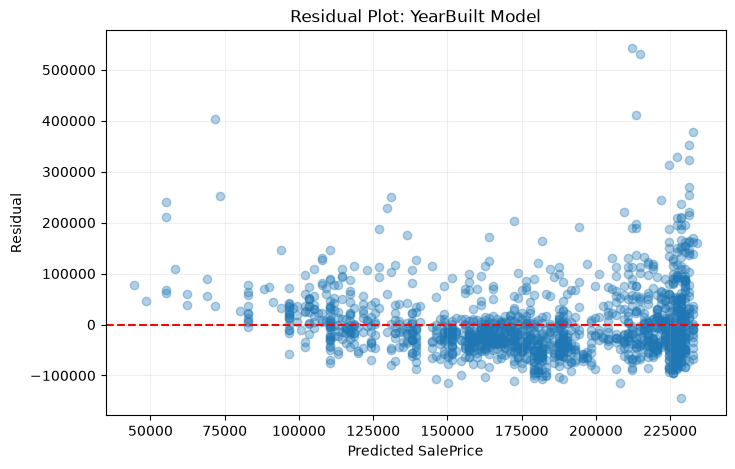

In [ ]:
# 여기에 코드를 작성하세요.
reg_data = df[["YearBuilt", "SalePrice"]].dropna()

x = reg_data["YearBuilt"].to_numpy(dtype=float)
y = reg_data["SalePrice"].to_numpy(dtype=float)

x_mean = x.mean()
y_mean = y.mean()

beta_1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
beta_0 = y_mean - beta_1 * x_mean

target_year = 2000
predicted_price_2000 = beta_0 + beta_1 * target_year

print(f"x 평균: {x_mean:.2f}")
print(f"y 평균: {y_mean:.2f}")
print(f"기울기 beta_1: {beta_1:.4f}")
print(f"절편 beta_0: {beta_0:.4f}")
print(f"회귀식: SalePrice = {beta_0:.4f} + {beta_1:.4f} × YearBuilt")
print(f"YearBuilt=2000 예측 가격: {predicted_price_2000:,.2f}")

y_pred = beta_0 + beta_1 * x
residuals = y - y_pred

sse = np.sum(residuals ** 2)
sst = np.sum((y - y_mean) ** 2)
r_squared = 1 - sse / sst

print(f"SSE = {sse:,.2f}")
print(f"SST = {sst:,.2f}")
print(f"R² = {r_squared:.4f}")

x_line = np.linspace(x.min(), x.max(), 200)
y_line = beta_0 + beta_1 * x_line

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.35, label="Observed")
plt.plot(x_line, y_line, color="red", linewidth=2, label="Regression line")
plt.xlabel("YearBuilt")
plt.ylabel("SalePrice")
plt.title("YearBuilt vs SalePrice")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.35)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Residual Plot: YearBuilt Model")
plt.grid(alpha=0.2)
plt.show()


> 문제 5번
- 회귀계수는 약 1,375.37로 건축 연도가 1년 증가할 때 예상 판매 가격은 평균적으로 약 1,375.37 달러 증가하는 것으로 나타났다.
- 절편은 약 -2,530,308.25로 계산되었지만 건축연도가 0일 때의 예상 판매 가격을 의미하므로 실제 데이터 범위를 크게 벗어나 현실적인 해석에는 한계가 있다.
- 결정계수 $R^2$은 약 0.2734로 건축 연도가 판매 가격 변동의 약 27.3%를 설명하는 것으로 나타나 설명력이 높다고 보기는 어렵다.
- 잔차 그래프에서는 예측 판매 가격이 높은 구간에서 잔차의 분산이 커지고 일부 큰 잔차도 나타나므로 회귀모형의 오차가 일정하지 않을 가능성이 있다.
- 따라서 건축 연도 하나만으로 판매 가격의 변동을 충분히 설명하기에는 한계가 있으며 다른 변수들도 함께 고려할 필요가 있다.
- 또한 회귀모형을 평가할 때는 $R^2$뿐만 아니라 잔차의 크기와 패턴도 함께 확인해야 한다.

---

## 실습 마무리

- 어떤 문제가 있었는가?
- 어떻게 개선했는가?
- 무엇을 근거로 개선되었다고 판단했는가?

$R^2$만 확인했을 때 놓칠 수 있는 점과 잔차 플롯을 추가했을 때 새롭게 확인한 내용을 중심으로 정리하세요.
